In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
n_samples = 200

sqft = np.random.randint(800, 3500, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
age = np.random.randint(1, 30, n_samples)
location = np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)

price = (sqft * 150) + (bedrooms * 10000) + (bathrooms * 15000) - (age * 2000) + np.random.normal(0, 20000, n_samples)
price = np.where(location == 'Urban', price + 50000, np.where(location == 'Suburban', price + 20000, price))

df = pd.DataFrame({
    'SquareFeet': sqft,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age': age,
    'Location': location,
    'Price': price
})

df.to_csv("house_prices.csv", index=False)
print("Dataset Created Successfully!")
df.head()


Dataset Created Successfully!


,SquareFeet,Bedrooms,Bathrooms,Age,Location,Price
0,1660,4,1,18,Rural,283285.043972
1,2094,3,3,28,Suburban,353315.963296
2,1930,3,3,26,Urban,380138.598208
3,1895,1,1,20,Suburban,255552.557221
4,2438,5,2,28,Urban,424740.600203


In [2]:
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 160
Testing samples: 40


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-Squared (R2) Score:", round(r2, 4))

Mean Squared Error (MSE): 623625177.44
Root Mean Squared Error (RMSE): 24972.49
R-Squared (R2) Score: 0.9363


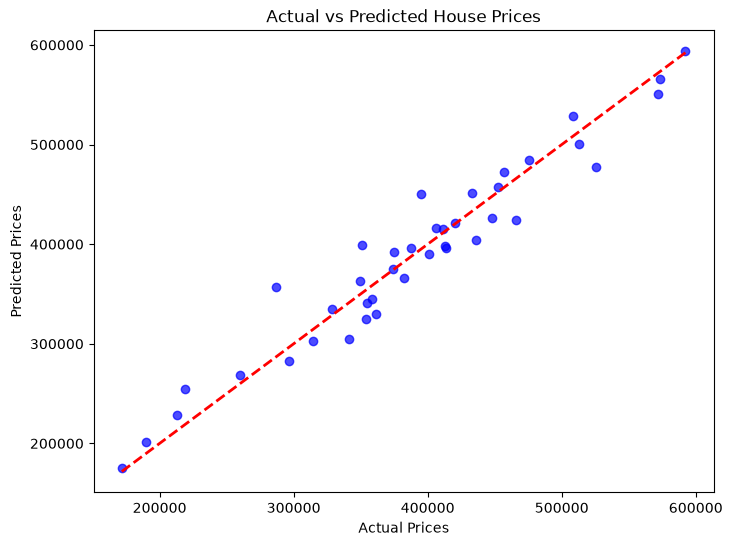

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()